In [1]:
!pip3 install -q pypdf langchain langchain-huggingface sentence-transformers faiss-cpu 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

/Users/sayanroy/Documents/Agentic AI Guide/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [12]:
## load the required details

# load the llm
llm    = ChatGroq(api_key = os.getenv("GROQ_API_KEY"), model = "openai/gpt-oss-20b")

# load the embeddings
embeddings = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")

# load the document
loader = PyPDFLoader("intro-to-ml.pdf")
docs   = loader.load()
print(len(docs))

# chunks the document
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
chunks   = splitter.split_documents(docs)
print(len(chunks))

# create the vector store
vectorstore = FAISS.from_documents(chunks, embeddings)

# create the retriever
retriever = vectorstore.as_retriever(search_type = "similarity", search_kwargs = {"k": 3})

392
973


In [13]:
## Define the tools

# rag tool to retrieve relevant information from the PDF document
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the PDF document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.

    Args:
        query (str): The query to retrieve relevant information from the PDF document.

    Returns:
        dict: A dictionary containing the query, context, and metadata.
    """
    result = retriever.invoke(query)

    context  = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {"query": query, "context": context, "metadata": metadata}

In [14]:
# Add the tools to our LLM model
tools          = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

# define the state of our LangGraph agent
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# define the nodes of our LangGraph
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

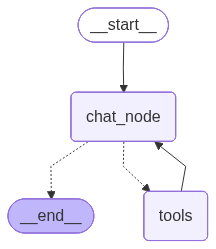

In [15]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile()
chatbot

In [ ]:
result = chatbot.invoke({
    "messages": [HumanMessage(content = "Using the pdf notes, explain how to find the ideal value of K in KNN?")]
})

print(result["messages"][-1].content)

In [18]:
from IPython.display import display, Markdown
display(Markdown(result["messages"][-1].content))

**How the book shows you to pick the “ideal” K for a k‑NN model**

> *“The k‑nearest neighbors algorithm is very easy to understand but it is also very sensitive to the choice of k. A very small k (e.g. 1) gives a model that follows the training data almost exactly – low bias, high variance. A very large k smooths the decision surface – high bias, low variance. The sweet spot is somewhere in the middle.”*  
> (Intro to ML with Python, § 2.2 “Choosing k”)

Below is a step‑by‑step outline that follows the notes, with a few code snippets that you can copy‑paste into a notebook.

---

### 1.  Set up a grid of candidate values

```python
from sklearn.neighbors import KNeighborsClassifier
neighbors = range(1, 11)          # 1 … 10 neighbors
```

The authors use the same range (1–10) in the notebook example that follows Figure 2‑7.

---

### 2.  Train and score each model on a hold‑out set

```python
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
        cancer.data, cancer.target,
        stratify=cancer.target, random_state=66)

train_acc, test_acc = [], []

for k in neighbors:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))
```

The book shows exactly this loop (see the notebook snippet in § 2.2, around page 49).  
It produces two curves:

* **Training accuracy** – almost 100 % for k = 1, dropping as k grows.
* **Test accuracy** – starts low for k = 1, rises to a peak, then falls again.

The figure (Figure 2‑7) illustrates that the best test accuracy occurs around **k = 6**.

---

### 3.  Visualise the bias–variance trade‑off

```python
import matplotlib.pyplot as plt

plt.plot(neighbors, train_acc, label='training accuracy')
plt.plot(neighbors, test_acc, label='test accuracy')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
```

The “elbow” where the test curve peaks is the practical indicator of the ideal k.

---

### 4.  Use cross‑validation for a more robust estimate

A single train/test split can be noisy. The notes recommend cross‑validation:

```python
from sklearn.model_selection import cross_val_score

# 5‑fold CV
cv_scores = {k: cross_val_score(KNeighborsClassifier(n_neighbors=k),
                                 X_train, y_train, cv=5).mean()
             for k in neighbors}

best_k = max(cv_scores, key=cv_scores.get)
print('Best k by CV:', best_k)
```

The book also shows how to automate this with `GridSearchCV`:

```python
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(neighbors)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print('Best k from GridSearchCV:', grid.best_params_['n_neighbors'])
```

Both approaches give the same conclusion as the simple hold‑out plot: **k around 5–7** works best for this dataset.

---

### 5.  Practical take‑aways

| What the notes emphasize | Why it matters |
|---------------------------|----------------|
| **Plot training vs. test accuracy** | Shows the bias–variance trade‑off and where the sweet spot is. |
| **Cross‑validation** | Gives a stable estimate that is not tied to one particular split. |
| **Start with 3–5 neighbors** | A common rule of thumb; the exact value depends on the data. |
| **Check the distance metric** | Euclidean is default, but other metrics may change the optimal k. |
| **Scale the features** | K‑NN is distance‑based; feature scaling can shift the optimal k. |

---

#### Bottom line

1. **Try a range of k values (e.g., 1–10).**  
2. **Plot training and test accuracy** (or use cross‑validation).  
3. **Pick the k that gives the highest test (or CV) accuracy** – usually somewhere in the middle.  
4. **Validate with a different split or CV** to confirm the choice.

The notes in *Introduction to Machine Learning with Python* walk you through exactly this process and show that for the breast‑cancer dataset the “ideal” k is around **6**. The same principle applies to any other dataset you work with.